## Config

In [1]:
import json
import pandas as pd
import numpy as np
import os

In [2]:
import spacy
nlp_spacy = spacy.load("en_core_web_sm")

import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import string
import re

[nltk_data] Downloading package punkt to /Users/gabrielvictorgomesferr
[nltk_data]     eira/opt/anaconda3/envs/nlp_env/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/gabrielvictorgomes
[nltk_data]     ferreira/opt/anaconda3/envs/nlp_env/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [4]:
import gensim
from gensim.models.phrases import Phraser, Phrases

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
from rake_nltk import Rake

In [7]:
# Load the config file
with open('../config/config.json', 'r') as f:
    config = json.load(f)

file_path = config["data_loc"]

## Datasets

### Trait Phrases Dataset

In [8]:
# Read trait data
file_name = "Trait dictionary.txt"
final_path = os.path.join(file_path, file_name) 

# Read trait dictionary file
with open(final_path, "r", encoding="utf-8") as file:
    trait_phrases = set([phrase.lower().strip() for phrase in file if phrase.strip()])

print(f"Number of good phrases in the trait dictionary: {len(trait_phrases)}")
# print(trait_phrases)

Number of good phrases in the trait dictionary: 22719


### Corpus Dataset

In [9]:
file_name = "QTL_text.json"
final_path = os.path.join(file_path, file_name) 

# Load json file
df = pd.read_json(final_path)
print(f"Shape of the original dataset: {df.shape}", "\n")

df.head()

Shape of the original dataset: (11278, 5) 



,PMID,Journal,Title,Abstract,Category
0,17179536,J Anim Sci. 2007 Jan;85(1):22-30.,Variance component analysis of quantitative tr...,"In a previous study, QTL for carcass compositi...",1
1,17177700,J Anim Breed Genet. 2006 Dec;123(6):414-8.,"Single nucleotide polymorphism identification,...",Pituitary adenylate cyclase-activating polypep...,0
2,17129674,Vet Parasitol. 2007 Apr 10;145(1-2):2-10. Epub...,Genetic resistance to Sarcocystis miescheriana...,Clinical and parasitological traits of Sarcocy...,0
3,17121599,Anim Genet. 2006 Dec;37(6):543-53.,Results of a whole-genome quantitative trait l...,A whole-genome quantitative trait locus (QTL) ...,1
4,17057239,Genetics. 2006 Dec;174(4):2119-27. Epub 2006 O...,Unexpected high polymorphism at the FABP4 gene...,Fatty acid bing protein 4 (FABP4) plays a key ...,0


## Pre-processing and other requirements

### Given Pre-Processing Requirements

In [10]:
# "In this project, you will need to use "Abstract" and "Category", and you can ignore the other fields."
df = df[['Abstract', 'Category']]
print(f"Shape before filtering: {df.shape}", "\n")

# "In this project, you need to ignore papers in Category ‘0’."
df = df[df['Category'] == 1].reset_index(drop=True)
print(f"Shape after filtering: {df.shape}", "\n")

df.head()

Shape before filtering: (11278, 2) 

Shape after filtering: (1007, 2) 



,Abstract,Category
0,"In a previous study, QTL for carcass compositi...",1
1,A whole-genome quantitative trait locus (QTL) ...,1
2,A partial genome scan using microsatellite mar...,1
3,BACKGROUND: The rate of pubertal development a...,1
4,"Previously, quantitative trait loci (QTL) for ...",1


### NLP Pre-Processing

- https://medium.com/@lingostat/tf-idf-for-text-preprocessing-in-machine-learning-a66b29774040

- https://www.linkedin.com/posts/bastyajayshenoy_nlp-preprocessing-ugcPost-7299663504242851840-6OIc/?utm_medium=ios_app&rcm=ACoAADH2sDkBuoJPDMiII65MByGi-S1MLFaY34s&utm_source=social_share_send&utm_campaign=whatsapp

In [11]:
# Set stop words
stop_words = set(stopwords.words('english'))

# Set lemmatizer
lemmatizer = WordNetLemmatizer()

# Defining NLP Pre-Processing steps. These steps were the one that highlighted the most on my exploration phase
def nlp_preprocessing(abstract_tokenized):
    abstract_tokenized = abstract_tokenized.apply(lambda doc: doc.lower()) # Lowercasing txt
    abstract_tokenized = abstract_tokenized.apply(lambda doc: doc.translate(str.maketrans("", "", string.punctuation))) # Removing punctuations from the text
    # abstract_tokenized = abstract_tokenized.apply(lambda doc: re.sub(r"\d+", "", doc)) # Removing numbers from the text
    abstract_tokenized = abstract_tokenized.apply(lambda doc: [token for token in word_tokenize(doc) if token not in stop_words]) # Tokenizing and removing stop words from the text
    abstract_tokenized = abstract_tokenized.apply(lambda doc: [lemmatizer.lemmatize(token, pos=wordnet.NOUN) for token in doc]) # Convert words to their base
    abstract_tokenized = abstract_tokenized.apply(lambda doc: [token.strip() for token in doc if token.strip() and len(token)>1]) # Removing extra space
    return abstract_tokenized

In [12]:
# Applying pre-defined pre-processing steps
df_processed = df.copy()
df_processed['abstract_nltk_token'] = nlp_preprocessing(df_processed['Abstract'])
df_processed['abstract_nltk_text'] = df_processed['abstract_nltk_token'].apply(lambda token: " ".join(token))
df_processed.head()

,Abstract,Category,abstract_nltk_token,abstract_nltk_text
0,"In a previous study, QTL for carcass compositi...",1,"[previous, study, qtl, carcass, composition, m...",previous study qtl carcass composition meat qu...
1,A whole-genome quantitative trait locus (QTL) ...,1,"[wholegenome, quantitative, trait, locus, qtl,...",wholegenome quantitative trait locus qtl scan ...
2,A partial genome scan using microsatellite mar...,1,"[partial, genome, scan, using, microsatellite,...",partial genome scan using microsatellite marke...
3,BACKGROUND: The rate of pubertal development a...,1,"[background, rate, pubertal, development, wean...",background rate pubertal development weaning e...
4,"Previously, quantitative trait loci (QTL) for ...",1,"[previously, quantitative, trait, locus, qtl, ...",previously quantitative trait locus qtl tenthr...


## Analysis

### Analysis Without Key-Phrases

#### Task 1
Use wordcloud to visualize words in this corpus. The figure should be 800*800, with white background color. You will need to generate two word cloud images: 1) use word frequency, and 2) use tf-idf 
You may find the following libraries useful for this task: WordCloud


##### 1) Frequency Base

In [13]:
# Define input text
input_text = " ".join(df_processed['abstract_nltk_text'])
# input_text

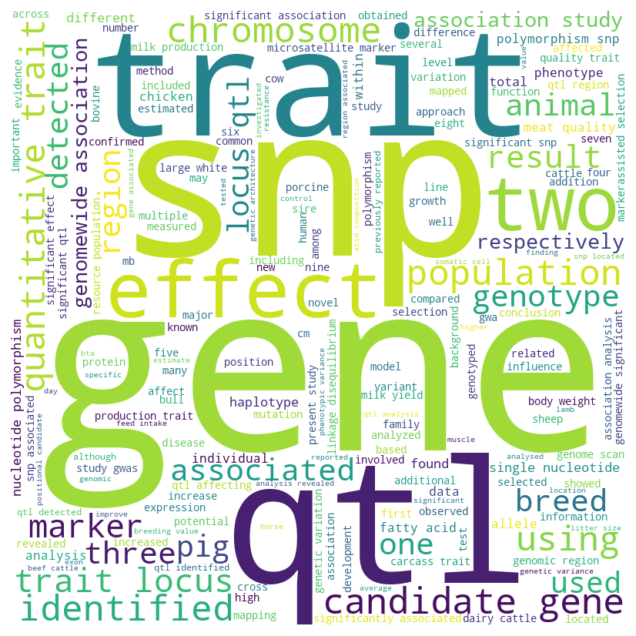

In [14]:
# Define word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white').generate(input_text)

# Display
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### 2) TF-IDF Base

- https://medium.com/@lingostat/tf-idf-for-text-preprocessing-in-machine-learning-a66b29774040

In [15]:
# Define input token
input_string = df_processed['abstract_nltk_token'].apply(lambda token: " ".join(token))
# input_string

In [16]:
# Compute TF-IDF
tfidf_vec = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(input_string)
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
tfidf_word = dict(zip(tfidf_vec.get_feature_names_out(), tfidf_scores))
# print(tfidf_word)

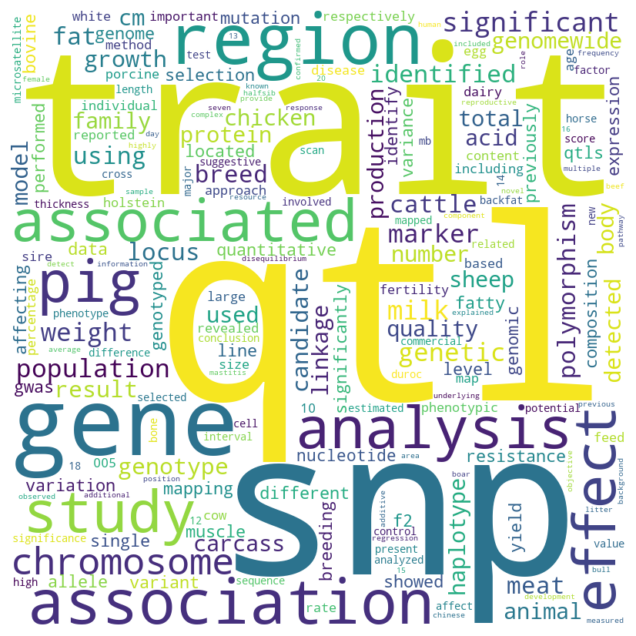

In [17]:
# Define word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white').generate_from_frequencies(tfidf_word)

# Display
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### Top TF-IDF Score Words

In [18]:
# Sort and print highest ranked words
top_words = sorted(tfidf_word.items(), key=lambda x: x[1], reverse=True)[:10]
top_words_list, top_scores_list = zip(*top_words)
for word, score in top_words:
    print(f"{word}: {round(score, 4)}")

qtl: 0.0613
trait: 0.0461
snp: 0.0458
gene: 0.0397
region: 0.0283
association: 0.026
associated: 0.0254
study: 0.0253
analysis: 0.0251
pig: 0.0249


#### Task 2 

Train a Word2Vec model on this corpus, with the following parameters
vector_size=100, window=5, min_count=10
For each of the top 10 tf-idf words, print the 20 most similar words.

- https://www.youtube.com/watch?v=Q2NtCcqmIww

In [19]:
# Document body
abstract_nltk = df_processed['abstract_nltk_token']

# Define model Word2Vec model
word2vec_model = gensim.models.Word2Vec(
    vector_size=100,
    window=5,
    min_count=10)

# Build Vocabulary
word2vec_model.build_vocab(abstract_nltk)

# Train model
word2vec_model.train(abstract_nltk, total_examples=word2vec_model.corpus_count, epochs=word2vec_model.epochs)

(545791, 767850)

In [20]:
# Dictionary to save values
most_similar_dict = {}

# Print and collect vales
for word in top_words:
    similar_words = word2vec_model.wv.most_similar(word[0], topn=20)
    print(f"{word[0]} → {', '.join([w[0] for w in similar_words])}")

    most_similar_dict[word[0]] = [(str(w[0]) + ":" + str(round(w[1], 4))) for w in similar_words]

# Create data-frame
df_test = pd.DataFrame.from_dict(most_similar_dict, orient='index')
df_test.index = range(1, len(df_test) + 1)
df_test.columns = [f"Similar {i+1}" for i in range(df_test.shape[1])]
df_test.insert(0, "Top Word", top_words_list)
df_test.insert(1, "TF-IDF Score", [round(score, 4) for score in top_scores_list])

df_test

qtl → qtls, previously, mapped, detected, reported, locus, identified, suggestive, region, several, chromosome, chromosomewide, chromosomal, putative, centromeric, 13, endocrine, quantitative, ssc7, evidence
trait → affecting, quantitative, locus, growth, endocrine, fatness, meat, underlying, economically, fertility, quality, carcass, related, affect, complex, eggshell, performance, important, qtls, influencing
snp → intron, haplotype, singlenucleotide, single, three, exon, five, nucleotide, revealed, two, showed, polymorphism, seven, flanking, within, four, one, promoter, six, 10
gene → candidate, positional, mutation, functional, several, involved, potential, bovine, variant, pathway, novel, causal, plausible, region, porcine, reported, coding, elovl6, function, promoter
region → identified, located, previously, mb, reported, within, novel, one, centromeric, chromosome, several, detected, mapped, putative, qtls, bovine, chromosomal, qtl, positional, mutation
association → gwas, genom

,Top Word,TF-IDF Score,Similar 1,Similar 2,Similar 3,Similar 4,Similar 5,Similar 6,Similar 7,Similar 8,...,Similar 11,Similar 12,Similar 13,Similar 14,Similar 15,Similar 16,Similar 17,Similar 18,Similar 19,Similar 20
1,qtl,0.0613,qtls:0.9591,previously:0.9437,mapped:0.9188,detected:0.9134,reported:0.9085,locus:0.8939,identified:0.8641,suggestive:0.8583,...,chromosome:0.8436,chromosomewide:0.8385,chromosomal:0.837,putative:0.8364,centromeric:0.8248,13:0.8147,endocrine:0.8143,quantitative:0.8135,ssc7:0.8067,evidence:0.8048
2,trait,0.0461,affecting:0.9423,quantitative:0.9033,locus:0.8955,growth:0.8875,endocrine:0.8636,fatness:0.8527,meat:0.8322,underlying:0.8261,...,quality:0.8217,carcass:0.8172,related:0.816,affect:0.8105,complex:0.8072,eggshell:0.7897,performance:0.7867,important:0.7833,qtls:0.783,influencing:0.7814
3,snp,0.0458,intron:0.92,haplotype:0.9088,singlenucleotide:0.9065,single:0.9054,three:0.9026,exon:0.9018,five:0.8986,nucleotide:0.8936,...,showed:0.8728,polymorphism:0.8708,seven:0.8533,flanking:0.8491,within:0.8421,four:0.8379,one:0.8313,promoter:0.8257,six:0.8222,10:0.8108
4,gene,0.0397,candidate:0.9701,positional:0.9408,mutation:0.8821,functional:0.8813,several:0.849,involved:0.8482,potential:0.8474,bovine:0.8449,...,novel:0.8182,causal:0.8145,plausible:0.8071,region:0.7994,porcine:0.79,reported:0.7885,coding:0.7858,elovl6:0.7771,function:0.7703,promoter:0.766
5,region,0.0283,identified:0.9682,located:0.9476,previously:0.9328,mb:0.9158,reported:0.9153,within:0.9047,novel:0.9041,one:0.9009,...,several:0.8857,detected:0.8819,mapped:0.8721,putative:0.8683,qtls:0.8607,bovine:0.8603,chromosomal:0.8585,qtl:0.857,positional:0.8537,mutation:0.8532
6,association,0.0260,gwas:0.938,genomewide:0.9298,analysis:0.9149,conducted:0.8898,gwa:0.8765,approach:0.8674,perform:0.867,singlenucleotide:0.8661,...,regression:0.8529,analyze:0.8441,imputed:0.843,result:0.8351,test:0.8349,highdensity:0.8336,study:0.8302,sequence:0.8265,multitrait:0.8248,mapping:0.8232
7,associated,0.0254,also:0.8975,significantly:0.893,found:0.8812,located:0.8122,fabp4:0.8067,highly:0.8044,receptor:0.8024,bta:0.8006,...,close:0.7913,several:0.7877,dgat1:0.7854,elovl6:0.7846,one:0.7824,near:0.7819,promising:0.7807,prkag3:0.779,respectively:0.7777,casein:0.776
8,study,0.0253,identify:0.9598,objective:0.9395,aim:0.927,present:0.9187,detect:0.9184,previous:0.8772,gwas:0.874,genomic:0.8638,...,fine:0.8425,scan:0.8386,genome:0.8344,association:0.8302,perform:0.8202,approach:0.8133,mapping:0.8113,performed:0.8113,result:0.8072,investigate:0.807
9,analysis,0.0251,genomewide:0.9518,linkage:0.9467,regression:0.945,disequilibrium:0.9388,mapping:0.9384,approach:0.9317,marker:0.9186,association:0.9149,...,test:0.9138,conducted:0.9117,gwa:0.9038,microsatellite:0.9001,ldla:0.8993,perform:0.8993,method:0.8976,based:0.8953,nonparametric:0.8953,combined:0.8911
10,pig,0.0249,commercial:0.9622,duroc:0.9535,resource:0.9463,chinese:0.9382,population:0.9355,chicken:0.9303,erhualian:0.9302,white:0.9274,...,leghorn:0.9213,landrace:0.9203,cross:0.9191,meishan:0.9143,rock:0.9125,intercross:0.9107,pietrain:0.9079,f2:0.9075,breed:0.9062,broiler:0.9044


### Analysis With Key-Phrases

### Task 3
Extract phrases and repeat task 1 and 2. You can be creative in phrase extraction. 


#### Key Phrase Extractor - Gensim

- https://tedboy.github.io/nlps/generated/generated/gensim.models.Phrases.html

- https://datascience.stackexchange.com/questions/25524/how-does-phrases-in-gensim-work

In [21]:
# Document Body
abstract_tokenized = df_processed['abstract_nltk_token']

In [22]:
# Bigram and trigram
bigram = Phraser(Phrases(abstract_tokenized, min_count=2, threshold=15))
trigram = Phraser(Phrases(bigram[abstract_tokenized], min_count=2, threshold=15))
bigram_token = [bigram[doc] for doc in abstract_tokenized]
trigram_token = [trigram[bigram[doc]] for doc in abstract_tokenized]
bigram_text = " ".join([" ".join(token) for token in bigram_token])
trigram_text = [" ".join(token) for token in trigram_token]
print(bigram_token[0])
# print(bigram_text)

['previous_study', 'qtl', 'carcass_composition', 'meat_quality', 'identified', 'commercial', 'finisher', 'cross', 'main_objective', 'current_study', 'confirm', 'fine_map', 'qtl', 'ssc4', 'ssc11', 'genotyping', 'increased', 'number', 'individual', 'marker', 'analyze_data', 'using', 'combined_linkage', 'linkage_disequilibrium', 'analysis', 'method', 'modified', 'version', 'method', 'excludes', 'linkage_disequilibrium', 'information', 'analysis', 'enabling', 'comparison', 'result', 'based', 'linkage', 'information', 'result', 'based', 'combined_linkage', 'linkage_disequilibrium', 'information', 'nine', 'additional', 'paternal_halfsib', 'family', 'genotyped', '18', 'marker', 'resulting', 'total', '1855', 'animal_genotyped', '15', '13', 'marker', 'ssc4', 'ssc11', 'respectively', 'qtl_affecting', 'meat_color', 'ssc4', 'confirmed', 'whereas', 'qtl_affecting', 'lm', 'weight', 'could_confirmed', 'combined_linkage', 'linkage_disequilibrium', 'analysis', 'resulted', 'identification', 'new', 'sign

In [86]:
len(set([token for doc in abstract_tokenized for token in doc]))

13344

In [85]:
len(set([token for doc in bigram_token for token in doc]))

16010

In [88]:
len(set([token for doc in abstract_tokenized for token in doc]).intersection(set([token for doc in bigram_token for token in doc])))

13066

In [ ]:
"meat" in trait_phrases

In [66]:
"meat" in trait_phrases

True

#### Task 3 -> Task 1 (Gensim)
Use wordcloud to visualize words in this corpus. The figure should be 800*800, with white background color. You will need to generate two word cloud images: 1) use word frequency, and 2) use tf-idf 
You may find the following libraries useful for this task: WordCloud

##### 1) Frequency Based

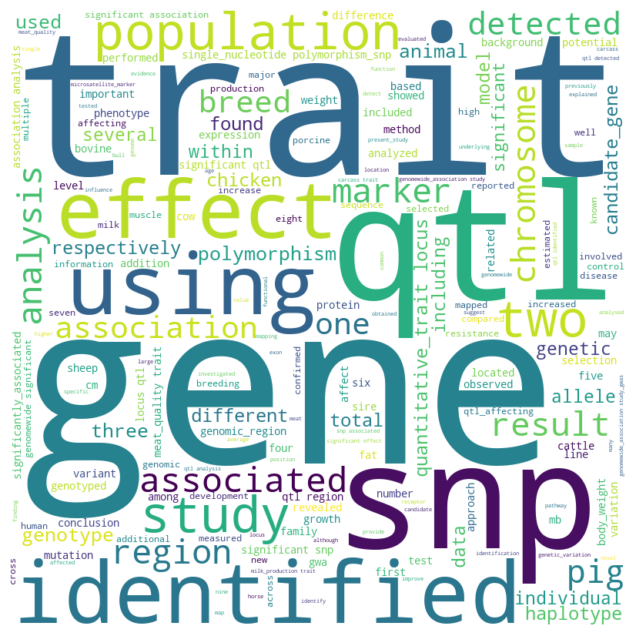

In [23]:
# Define word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white').generate(bigram_text)

# Display
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### 2) TF-IDF Score Base

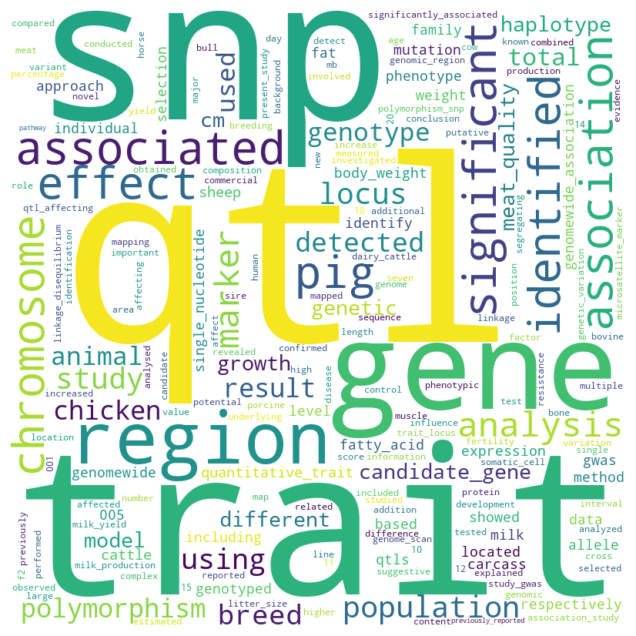

In [24]:
# Compute TF-IDF
tfidf_vec = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform([" ".join(token) for token in bigram_token])

tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
tfidf_word = dict(zip(tfidf_vec.get_feature_names_out(), tfidf_scores))

# Define word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white').generate_from_frequencies(tfidf_word)

# Display
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [25]:
# Sort highest ranked words
top_words = sorted(tfidf_word.items(), key=lambda x: x[1], reverse=True)[:10]
top_words_list, top_scores_list = zip(*top_words)

for word, score in top_words:
    print(f"{word}: {round(score, 4)}")

qtl: 0.0597
trait: 0.0435
snp: 0.042
gene: 0.034
region: 0.0244
associated: 0.0232
significant: 0.023
association: 0.0225
pig: 0.0221
effect: 0.0221


##### Task 3 -> Task 2 (Gensim)

Train a Word2Vec model on this corpus, with the following parameters
vector_size=100, window=5, min_count=10
For each of the top 10 tf-idf words, print the 20 most similar words.

In [26]:
# Define model Word2Vec model
word2vec_model = gensim.models.Word2Vec(
    vector_size=100,
    window=5,
    min_count=10)

# Build Vocabulary
word2vec_model.build_vocab(bigram_token)

# Train model
word2vec_model.train(bigram_token, total_examples=word2vec_model.corpus_count, epochs=word2vec_model.epochs)


(404763, 648925)

In [27]:
# Dictionary to save values
most_similar_dict = {}

# Print and collect vales
for word in top_words:
    similar_words = word2vec_model.wv.most_similar(word[0], topn=20)
    print(f"{word[0]} → {', '.join([w[0] for w in similar_words])}")

    most_similar_dict[word[0]] = [(str(w[0]) + ":" + str(round(w[1], 4))) for w in similar_words]

# Create data-frame
df_test = pd.DataFrame.from_dict(most_similar_dict, orient='index')
df_test.index = range(1, len(df_test) + 1)
df_test.columns = [f"Similar {i+1}" for i in range(df_test.shape[1])]
df_test.insert(0, "Top Word", top_words_list)
df_test.insert(1, "TF-IDF Score", [round(score, 4) for score in top_scores_list])

df_test

qtl → chromosome, region, identified, suggestive, detected, qtls, genomewide, significant, mb, located, one, found, mapped, respectively, four, level, 12, 10, ssc7, nine
trait → carcass, growth, affect, meat, content, meat_quality, important, percentage, however, abdominal_fat, specific, intramuscular_fat, increase, backfat, proportion, muscle, could, major, genetic_architecture, yield
snp → genomewide, found, detected, located, significantly_associated, respectively, suggestive, four, one, mb, 005, five, significant, identified, two, 10, association, three, nine, 12
gene → candidate_gene, protein, involved, porcine, role, positional_candidate, potential, skeletal_muscle, development, related, receptor, known, bovine, investigate, coding, function, expression, variant, variation, mutation
region → located, mb, identified, one, detected, suggestive, found, chromosome, qtls, genomewide, respectively, qtl, four, mapped, significant, level, 10, 12, significantly_associated, nine
associated

,Top Word,TF-IDF Score,Similar 1,Similar 2,Similar 3,Similar 4,Similar 5,Similar 6,Similar 7,Similar 8,...,Similar 11,Similar 12,Similar 13,Similar 14,Similar 15,Similar 16,Similar 17,Similar 18,Similar 19,Similar 20
1,qtl,0.0597,chromosome:0.9945,region:0.9921,identified:0.9909,suggestive:0.9908,detected:0.9905,qtls:0.9901,genomewide:0.989,significant:0.9883,...,one:0.9862,found:0.9854,mapped:0.9826,respectively:0.9824,four:0.9805,level:0.9779,12:0.9773,10:0.9773,ssc7:0.9768,nine:0.9766
2,trait,0.0435,carcass:0.9983,growth:0.9982,affect:0.9977,meat:0.9973,content:0.9972,meat_quality:0.9971,important:0.9971,percentage:0.997,...,specific:0.9969,intramuscular_fat:0.9968,increase:0.9968,backfat:0.9968,proportion:0.9968,muscle:0.9968,could:0.9967,major:0.9967,genetic_architecture:0.9967,yield:0.9967
3,snp,0.0420,genomewide:0.994,found:0.9937,detected:0.9925,located:0.992,significantly_associated:0.9918,respectively:0.9917,suggestive:0.9913,four:0.9911,...,005:0.99,five:0.9899,significant:0.9896,identified:0.9893,two:0.9892,10:0.9887,association:0.9886,three:0.9886,nine:0.9874,12:0.9874
4,gene,0.0340,candidate_gene:0.9956,protein:0.9954,involved:0.9952,porcine:0.9951,role:0.995,positional_candidate:0.995,potential:0.9949,skeletal_muscle:0.9948,...,receptor:0.9947,known:0.9947,bovine:0.9947,investigate:0.9946,coding:0.9946,function:0.9946,expression:0.9945,variant:0.9945,variation:0.9943,mutation:0.9943
5,region,0.0244,located:0.9974,mb:0.9971,identified:0.9962,one:0.9959,detected:0.9958,suggestive:0.9952,found:0.9951,chromosome:0.994,...,respectively:0.9926,qtl:0.9921,four:0.9914,mapped:0.9909,significant:0.989,level:0.9888,10:0.9888,12:0.9888,significantly_associated:0.9879,nine:0.9877
6,associated,0.0232,novel:0.9986,previously_reported:0.998,located_within:0.9979,revealed:0.9979,within:0.9978,seven:0.9978,two:0.9977,six:0.9977,...,five:0.9973,genomic_region:0.9973,ssc8:0.9972,ssc2:0.9971,four:0.9971,ssc1:0.9971,candidate_gene:0.997,chromosome_10:0.997,several:0.997,11:0.997
7,significant,0.0230,genomewide:0.9956,chromosome:0.9953,identified:0.993,located:0.9909,detected:0.9907,suggestive:0.9902,snp:0.9896,found:0.9892,...,qtl:0.9883,one:0.985,respectively:0.9834,qtls:0.9819,four:0.9805,005:0.9784,significantly_associated:0.9779,10:0.9757,level:0.9756,two:0.9746
8,association,0.0225,three:0.9956,five:0.9952,showed:0.9952,haplotype:0.9951,total:0.9949,marker:0.9947,seven:0.9946,six:0.9945,...,analysis:0.9937,analysis_revealed:0.9937,showed_significant:0.9936,significantly_associated:0.9935,additional:0.9935,promoter_region:0.9934,novel:0.9933,eight:0.9932,single:0.9932,11:0.9932
9,pig,0.0221,sheep:0.9985,cattle:0.9984,population:0.9982,breeding:0.9982,commercial:0.998,improve:0.9978,complex:0.9978,disease:0.9977,...,genetic_basis:0.9976,dairy:0.9976,breeding_program:0.9975,background:0.9975,phenotype:0.9975,architecture:0.9975,f2:0.9974,therefore:0.9974,experimental:0.9974,production:0.9973
10,effect,0.0221,also:0.9986,001:0.9982,showed_significant:0.9981,addition:0.9981,0001:0.998,number:0.9979,ssc8:0.9978,putative:0.9978,...,p005:0.9978,genetic_variance:0.9978,significance:0.9978,revealed:0.9978,threshold:0.9978,rfi:0.9978,evidence:0.9977,ssc4:0.9977,analysis_revealed:0.9977,variance:0.9977


#### Main result (Gensim): 
- 3.	How many phrases you extracted can be found in the trait dictionary (by exact string matching)? 

In [28]:
print(f"Number of good phrases in the trait dictionary: {len(trait_phrases)}")
# print(trait_phrases)

Number of good phrases in the trait dictionary: 22719


In [50]:
bi_unique = set()
# bi_good_phrases = [[token for token in doc if "_" in token] for doc in bigram_token]
bi_good_phrases = [[token.replace("_", " ") for token in doc] for doc in bigram_token]

for doc in bi_good_phrases:
    bi_unique.update(doc) 

print(f"Number of good phrases in the trait dictionary: {len(bi_unique)}")
# print(bi_unique)

Number of good phrases in the trait dictionary: 16010


##### Analysis

In [30]:
# Calculate key phrase coverage
coverage_percentage = round(len(bi_unique) / len(trait_phrases) * 100, 2)
print(f"The key phrase extractor identified the equivalent of {coverage_percentage}% of the key phrases number present in the trait file.")

The key phrase extractor identified the equivalent of 70.47% of the key phrases number present in the trait file.


In [51]:
bi_good_phrases

[['previous study',
  'qtl',
  'carcass composition',
  'meat quality',
  'identified',
  'commercial',
  'finisher',
  'cross',
  'main objective',
  'current study',
  'confirm',
  'fine map',
  'qtl',
  'ssc4',
  'ssc11',
  'genotyping',
  'increased',
  'number',
  'individual',
  'marker',
  'analyze data',
  'using',
  'combined linkage',
  'linkage disequilibrium',
  'analysis',
  'method',
  'modified',
  'version',
  'method',
  'excludes',
  'linkage disequilibrium',
  'information',
  'analysis',
  'enabling',
  'comparison',
  'result',
  'based',
  'linkage',
  'information',
  'result',
  'based',
  'combined linkage',
  'linkage disequilibrium',
  'information',
  'nine',
  'additional',
  'paternal halfsib',
  'family',
  'genotyped',
  '18',
  'marker',
  'resulting',
  'total',
  '1855',
  'animal genotyped',
  '15',
  '13',
  'marker',
  'ssc4',
  'ssc11',
  'respectively',
  'qtl affecting',
  'meat color',
  'ssc4',
  'confirmed',
  'whereas',
  'qtl affecting',
  

In [48]:
trait_phrases

{'liver regeneration trait',
 'pituitary tumor incidence/prevalence measurement',
 'serum t3 level',
 'oesophagus morphology',
 'percentage',
 'cd8+ t cell number',
 'number of squamous cell tumors of the head and neck',
 'total glomeruli count',
 'liver fibrosis area measurement',
 'exocrine pancreas morphology trait',
 'splenic periarteriolar lymphoid sheath morphology trait',
 'rostral migratory stream morphology trait',
 'hippocampal neuron number',
 'ctl morphology',
 'circulating b-cell growth factor-i level',
 'energy expenditure',
 'milk chloride amount',
 'colostrum immunoglobulin a concentration',
 'number of all cells in that exudate',
 'metallophilic macrophage',
 'neurocranium mass',
 'blood ige level',
 'cochlear hair cell quantity',
 'myocardium morphology trait',
 'calculated femur midshaft cross-sectional',
 'muscle unsaturated fatty acid',
 'milk fatty acid trans-12,cis-14-c18:2 concentration',
 'palatine gland ductal branching',
 'egl',
 'blood gonadotropin',
 'milk 

In [52]:
bi_unique

{'0008',
 'repulsion',
 'blueshelled chicken',
 'solely',
 'lactationaverage',
 'percentage',
 'ggaluga348518',
 '12fold',
 'glikruppel',
 'molecular basis',
 'mogat1',
 '00100',
 'vaccinationchallenge',
 'leptin receptor',
 '356×1066',
 'present',
 'creatinine',
 'cumulus',
 '148',
 '027',
 '190',
 'nakatpase',
 'mq',
 'det1',
 '19',
 'thereby',
 'deviation unit',
 'recprotein',
 'baseline',
 '605',
 'fitted',
 'gg',
 'ile442',
 'odds infection',
 'external',
 '110 cm',
 'rtpolymerase',
 'hold',
 'mica',
 'high heritability',
 'highheritability',
 'cytological',
 'maf005',
 '45',
 'retardation',
 'moderate heritability',
 'nexin',
 'ghsr',
 'catabolic',
 'erhualian cross',
 'grouphoused',
 'cellrelated',
 'bovine tuberculosis',
 'sw1495',
 'geneticist',
 'asppcr',
 'oneqtl',
 'n153',
 'qtlvariance',
 'hco3',
 '124',
 '1490',
 'reactor skin',
 'endocrine',
 'tenfold',
 'equidistant',
 'remarkable',
 'earless',
 'separation',
 'su wld',
 'impairment',
 'palmitic palmitoleic',
 'avfec',


In [53]:
# Compare gensim vs. trait phrases
matching_phrases = bi_unique & trait_phrases
match_count = len(matching_phrases)

# Calculate percentage representation
match_percentage = round((match_count / len(trait_phrases)) * 100, 2)

print(f"Total Exact Matches: {match_count}")
print(f"This represents {match_percentage}% of all phrases in the trait dictionary. \n")

Total Exact Matches: 400
This represents 1.76% of all phrases in the trait dictionary. 



In [54]:
print("Summary")
print(f"Our extractor captured the equivalent of {coverage_percentage}% of the key phrases, but only {match_percentage}% were exact matches to known trait phrases.")
print("Matching Phrases:", list(matching_phrases))

Summary
Our extractor captured the equivalent of 97.91% of the key phrases, but only 1.76% were exact matches to known trait phrases.
Matching Phrases: ['abdominal fat', 'percentage', 'morphology', 'metabolism', 'fat thickness', 'milk protein', 'phagocytosis', 'count', 'baseline', 'limb', 'ap', 'triglyceride level', 'balance', 'sperm motility', 'oleic acid', 'adrenal gland', 'pericardium', 'infection', 'ovulation', 'meat', 'bone density', 'carcass', 'tibia length', 'milk', 'tender', 'scapula', 'bacterial', 'birth', 'scrotal circumference', 'gland', 'homeostasis', 'ldl', 'epidermis', 'ear', 'immunoglobulin', 'consumption', 'ejaculation', 'leg', 'shank diameter', 'litter size', 'dermis', 'wool', 'keel', 'serum lipid', 'semen', 'synapse', 'tail', 'novelty', 'rearing', 'hematocrit', 'semen volume', 'length', 'wound healing', 'triglyceride', 'body conformation', 'splenic', 'muscle fiber', 'chest', 'neutrophil', 'tibia', 'connective tissue', 'shank', 'offspring', 'facial', 'acth', 'pelvis', 

#### Key Phrase Extractor - Rake

In [33]:
# Define Rake Extractor
r = Rake(stopwords=stop_words, punctuations=string.punctuation, min_length=1, max_length=3)

# Extract RAKE key phrases per document
df_processed["key_phrases_rake"] = df_processed["Abstract"].apply(
    lambda text: r.extract_keywords_from_text(text) or [phrase for score, phrase in r.get_ranked_phrases_with_scores() if score > 5]
)

# Preprocess key phrases and merge with documents
df_processed["processed_key_phrases"] = df_processed["key_phrases_rake"].apply(lambda phrases: ["_".join(nlp_preprocessing(pd.Series([phrase]))[0]) for phrase in phrases])

# Merge key phrases back into original documents
df_processed["abstract_rake_token"] = df_processed.apply(lambda row: row["abstract_nltk_token"] + row["processed_key_phrases"], axis=1)
df_processed['abstract_rake_text'] = df_processed['abstract_rake_token'].apply(lambda token: " ".join(token))
df_processed.head()

,Abstract,Category,abstract_nltk_token,abstract_nltk_text,key_phrases_rake,processed_key_phrases,abstract_rake_token,abstract_rake_text
0,"In a previous study, QTL for carcass compositi...",1,"[previous, study, qtl, carcass, composition, m...",previous study qtl carcass composition meat qu...,"[take full advantage, new significant effects,...","[take_full_advantage, new_significant_effect, ...","[previous, study, qtl, carcass, composition, m...",previous study qtl carcass composition meat qu...
1,A whole-genome quantitative trait locus (QTL) ...,1,"[wholegenome, quantitative, trait, locus, qtl,...",wholegenome quantitative trait locus qtl scan ...,"[entire porcine genome, based nonparametric ap...","[entire_porcine_genome, based_nonparametric_ap...","[wholegenome, quantitative, trait, locus, qtl,...",wholegenome quantitative trait locus qtl scan ...
2,A partial genome scan using microsatellite mar...,1,"[partial, genome, scan, using, microsatellite,...",partial genome scan using microsatellite marke...,"[porcine resource population, marker loci sw13...","[porcine_resource_population, marker_locus_sw1...","[partial, genome, scan, using, microsatellite,...",partial genome scan using microsatellite marke...
3,BACKGROUND: The rate of pubertal development a...,1,"[background, rate, pubertal, development, wean...",background rate pubertal development weaning e...,"[usmarc resource population, specific hydroxys...","[usmarc_resource_population, specific_hydroxys...","[background, rate, pubertal, development, wean...",background rate pubertal development weaning e...
4,"Previously, quantitative trait loci (QTL) for ...",1,"[previously, quantitative, trait, locus, qtl, ...",previously quantitative trait locus qtl tenthr...,"[quantitative trait loci, loin eye area, janus...","[quantitative_trait_locus, loin_eye_area, janu...","[previously, quantitative, trait, locus, qtl, ...",previously quantitative trait locus qtl tenthr...


#### Task 3 -> Task 1 (Rake)
Use wordcloud to visualize words in this corpus. The figure should be 800*800, with white background color. You will need to generate two word cloud images: 1) use word frequency, and 2) use tf-idf 
You may find the following libraries useful for this task: WordCloud

##### 1) Frequency Based

In [34]:
input_text_rake = " ".join(df_processed['abstract_rake_text'])
# input_text_rake

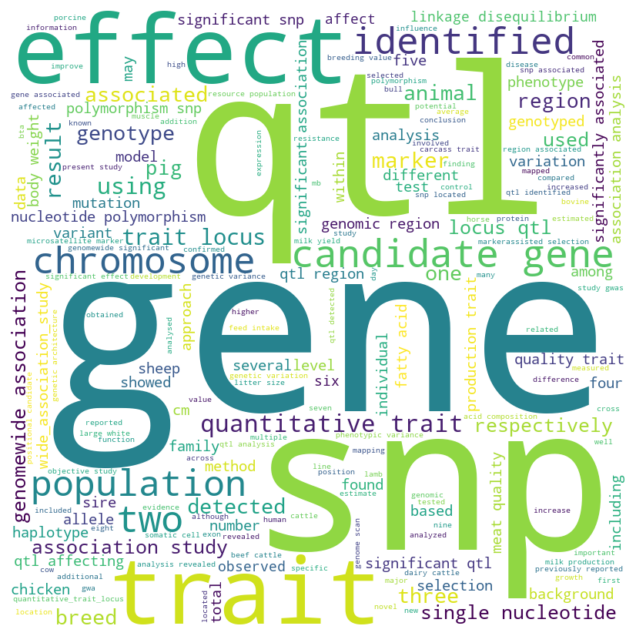

In [35]:
# Define word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white').generate(input_text_rake)

# Display
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### 2) TF-IDF Score Base

In [36]:
# Define input token
input_string = df_processed['abstract_rake_token'].apply(lambda token: " ".join(token))
# input_string

In [37]:
# Compute TF-IDF
tfidf_vec = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vec.fit_transform(input_string)
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
tfidf_word = dict(zip(tfidf_vec.get_feature_names_out(), tfidf_scores))
# print(tfidf_word)

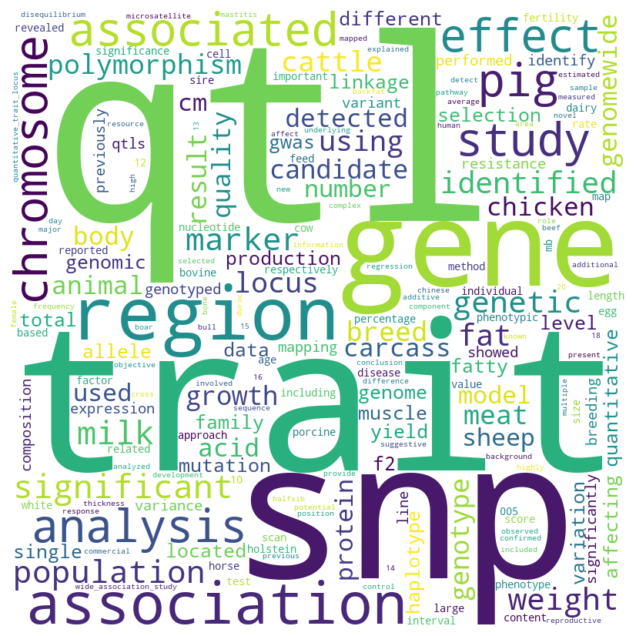

In [38]:
# Define word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white').generate_from_frequencies(tfidf_word)

# Display
plt.figure(figsize=(8,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

##### Top TF-IDF Score Words

In [39]:
# Sort and print highest ranked words
top_words = sorted(tfidf_word.items(), key=lambda x: x[1], reverse=True)[:10]
top_words_list, top_scores_list = zip(*top_words)
for word, score in top_words:
    print(f"{word}: {round(score, 4)}")

qtl: 0.0573
trait: 0.0432
snp: 0.0431
gene: 0.0374
region: 0.0265
association: 0.0245
associated: 0.0239
study: 0.0237
analysis: 0.0235
pig: 0.0234


##### Task 3 -> Task 2 (Rake)

Train a Word2Vec model on this corpus, with the following parameters
vector_size=100, window=5, min_count=10
For each of the top 10 tf-idf words, print the 20 most similar words.

In [40]:
# Document body
abstract_nltk = df_processed['abstract_rake_token']

# Define model Word2Vec model
word2vec_model = gensim.models.Word2Vec(
    vector_size=100,
    window=5,
    min_count=10)

# Build Vocabulary
word2vec_model.build_vocab(abstract_nltk)

# Train model
word2vec_model.train(abstract_nltk, total_examples=word2vec_model.corpus_count, epochs=word2vec_model.epochs)

(555415, 829860)

In [41]:
# Dictionary to save values
most_similar_dict = {}

# Print and collect vales
for word in top_words:
    similar_words = word2vec_model.wv.most_similar(word[0], topn=20)
    print(f"{word[0]} → {', '.join([w[0] for w in similar_words])}")

    most_similar_dict[word[0]] = [(str(w[0]) + ":" + str(round(w[1], 4))) for w in similar_words]

# Create data-frame
df_test = pd.DataFrame.from_dict(most_similar_dict, orient='index')
df_test.index = range(1, len(df_test) + 1)
df_test.columns = [f"Similar {i+1}" for i in range(df_test.shape[1])]
df_test.insert(0, "Top Word", top_words_list)
df_test.insert(1, "TF-IDF Score", [round(score, 4) for score in top_scores_list])

df_test

qtl → qtls, detected, mapped, suggestive, previously, reported, chromosome, four, chromosomewide, 13, mb, 14, region, significant, found, identified, chromosomal, locus, 11, several
trait → affecting, quantitative, locus, growth, fatness, meat, quality, fertility, carcass, economically, influencing, affect, production, endocrine, eggshell, related, bone, complex, underlying, tenderness
snp → single, exon, three, haplotype, revealed, singlenucleotide, nucleotide, five, intron, polymorphism, two, one, showed, seven, within, six, flanking, identified, novel, sequence
gene → candidate, positional, mutation, potential, bovine, involved, several, functional, causal, pathway, porcine, variant, plausible, region, reported, promising, function, known, receptor, scd
region → identified, located, mb, previously, within, reported, novel, bovine, several, one, detected, chromosome, putative, found, intron, near, four, mutation, 14, mapped
association → genomewide, gwas, analysis, gwa, conducted, re

,Top Word,TF-IDF Score,Similar 1,Similar 2,Similar 3,Similar 4,Similar 5,Similar 6,Similar 7,Similar 8,...,Similar 11,Similar 12,Similar 13,Similar 14,Similar 15,Similar 16,Similar 17,Similar 18,Similar 19,Similar 20
1,qtl,0.0573,qtls:0.9587,detected:0.9388,mapped:0.9322,suggestive:0.9095,previously:0.9001,reported:0.8889,chromosome:0.8829,four:0.8644,...,mb:0.8555,14:0.853,region:0.853,significant:0.8492,found:0.8478,identified:0.8477,chromosomal:0.8447,locus:0.843,11:0.8396,several:0.8337
2,trait,0.0432,affecting:0.9222,quantitative:0.8914,locus:0.8842,growth:0.868,fatness:0.8618,meat:0.8298,quality:0.8272,fertility:0.8143,...,influencing:0.7767,affect:0.7766,production:0.7717,endocrine:0.7696,eggshell:0.7656,related:0.7581,bone:0.7529,complex:0.7474,underlying:0.7466,tenderness:0.7466
3,snp,0.0431,single:0.9191,exon:0.9055,three:0.8987,haplotype:0.8962,revealed:0.8932,singlenucleotide:0.8922,nucleotide:0.8922,five:0.8901,...,two:0.8776,one:0.8583,showed:0.8507,seven:0.85,within:0.8462,six:0.8323,flanking:0.8309,identified:0.8231,novel:0.821,sequence:0.8177
4,gene,0.0374,candidate:0.9803,positional:0.9381,mutation:0.8939,potential:0.8511,bovine:0.847,involved:0.8466,several:0.8416,functional:0.8351,...,porcine:0.8054,variant:0.8011,plausible:0.7953,region:0.7922,reported:0.7867,promising:0.7827,function:0.782,known:0.7796,receptor:0.7783,scd:0.7675
5,region,0.0265,identified:0.9767,located:0.9739,mb:0.9408,previously:0.9383,within:0.9276,reported:0.912,novel:0.9108,bovine:0.9084,...,detected:0.8934,chromosome:0.8905,putative:0.8817,found:0.8769,intron:0.8726,near:0.8714,four:0.868,mutation:0.868,14:0.8678,mapped:0.8668
6,association,0.0245,genomewide:0.9537,gwas:0.9286,analysis:0.9162,gwa:0.8729,conducted:0.8713,revealed:0.8688,performed:0.8682,previous:0.8667,...,imputed:0.8378,result:0.8329,study:0.8314,approach:0.8304,regression:0.8269,mapping:0.8247,chip:0.8135,detect:0.8083,single:0.8082,haplotypebased:0.8034
7,associated,0.0239,significantly:0.9126,found:0.9062,also:0.8947,qtls:0.854,fabp4:0.8536,several:0.8382,coincided:0.8257,mutation:0.8216,...,highly:0.8081,bovine:0.8081,near:0.8072,close:0.8035,promising:0.8026,located:0.8018,linked:0.7968,one:0.7947,harbouring:0.7945,cw:0.792
8,study,0.0237,objective:0.923,identify:0.9201,detect:0.9176,gwas:0.9159,aim:0.9104,present:0.8991,conducted:0.8863,previous:0.8707,...,perform:0.8589,genome:0.8519,scan:0.8516,approach:0.8364,association:0.8314,gwa:0.831,genomewide:0.8287,conduct:0.8266,result:0.8235,fine:0.819
9,analysis,0.0235,regression:0.9608,genomewide:0.9507,mapping:0.945,disequilibrium:0.9407,gwa:0.9385,linkage:0.9369,approach:0.9352,gwas:0.9239,...,association:0.9162,performed:0.9155,perform:0.9061,marker:0.9002,combined:0.8995,imputed:0.8988,microsatellite:0.8963,test:0.895,using:0.8947,mixed:0.8944
10,pig,0.0234,commercial:0.9615,resource:0.9574,duroc:0.9486,chinese:0.9437,rock:0.9351,sutai:0.9329,erhualian:0.9319,breed:0.9314,...,cross:0.9292,population:0.9248,meishan:0.9236,dongxiang:0.9222,pietrain:0.919,intercross:0.9151,white:0.9131,landrace:0.9129,broiler:0.9111,japanese:0.9078


#### Main result (Rake): 
- 3.	How many phrases you extracted can be found in the trait dictionary (by exact string matching)? 

https://www.youtube.com/watch?v=O43XPHC_DEs

In [42]:
print(f"Number of good phrases in the trait dictionary: {len(trait_phrases)}")
# print(trait_phrases)

Number of good phrases in the trait dictionary: 22719


In [43]:
bi_unique = set()
good_phrases = df_processed['abstract_rake_token']
for doc in good_phrases:
    bi_unique.update(doc) 

print(f"Number of good phrases in the trait dictionary: {len(bi_unique)}")
# print(bi_unique)

Number of good phrases in the trait dictionary: 22245


##### Analysis

In [44]:
# Calculate key phrase coverage
coverage_percentage = round(len(bi_unique) / len(trait_phrases) * 100, 2)
print(f"The key phrase extractor identified the equivalent of {coverage_percentage}% of the key phrases number present in the trait file.")

The key phrase extractor identified the equivalent of 97.91% of the key phrases number present in the trait file.


In [45]:
# Compare gensim vs. trait phrases
matching_phrases = bi_unique & trait_phrases
match_count = len(matching_phrases)

# Calculate percentage representation
match_percentage = round((match_count / len(trait_phrases)) * 100, 2)

print(f"Total Exact Matches: {match_count}")
print(f"This represents {match_percentage}% of all phrases in the trait dictionary. \n")

Total Exact Matches: 286
This represents 1.26% of all phrases in the trait dictionary. 



In [46]:
print("Summary")
print(f"Our extractor captured the equivalent of {coverage_percentage}% of the key phrases, but only {match_percentage}% were exact matches to known trait phrases.")
print("Matching Phrases:", list(matching_phrases))

Summary
Our extractor captured the equivalent of 97.91% of the key phrases, but only 1.26% were exact matches to known trait phrases.
Matching Phrases: ['blood', 'spine', 'dressing', 'radius', 'egg', 'osteoclast', 'osteogenesis', 'percentage', 'morphology', 'infarction', 'clinical', 'digestion', 'protein', 'temperament', 'vasculogenesis', 'shoulder', 'sarcomere', 'appendage', 'response', 'metabolism', 'sclerotome', 'lung', 'trait', 'bone', 'organism', 'metatarsus', 'interleukin', 'phagocytosis', 'cns', 'count', 'semimembranosus', 'corticotropin', 'cecum', 'gastric', 'ap', 'weight', 'baseline', 'limb', 'dopaminergic', 'lymphocyte', 'balance', 'dopamine', 'level', 'albumin', 'ca', 'liver', 'chemokine', 'litter', 'lymphoma', 'pericardium', 'infection', 'ribeye', 'monocyte', 'ovulation', 'jowl', 'perineum', 't4', 'joint', 'spermatozoon', 'meat', 'nipple', 'sensory', 'number', 'vertebrate', 'marbling', 'carcass', 'hdl', 'behavior', 'mortality', 'production', 'tarsometatarsus', 'milk', 'scap